# Análisis exploratorio de datos — AI4I 2020

## Objetivo

Comprender el comportamiento estadístico y las relaciones entre las variables del dataset AI4I 2020 antes del preprocesamiento y modelado, con el fin de justificar las decisiones tomadas durante la etapa de ingeniería de características y garantizar que cada decisión optimice la capacidad predictiva de los modelos de detección de anomalías.

Este análisis será la base para diseñar y construir un pipeline automatizado y reproducible que transforme los datos crudos en variables óptimas para los algoritmos de Machine Learning.

Debido a que previamente se realizó un diagnóstico de calidad de los datos, en esta sección no se repiten las verificaciones, ni los análisis ya realizados en ese analisis. Estos se mencionaran cuando el resultado y el análisis requieran acción en la etapa posterior o un algún análisis adicional. 

In [45]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy import stats
import numpy as np


In [46]:
# Identificar la raíz del proyecto de forma independiente
# del lugar desde donde se ejecute el notebook.
RUTA_PROYECTO = Path.cwd()

if RUTA_PROYECTO.name == "notebooks":
    RUTA_PROYECTO = RUTA_PROYECTO.parent

RUTA_DATOS = RUTA_PROYECTO / "data" / "raw" / "ai4i2020.csv"

print(f"Ruta del dataset: {RUTA_DATOS}")
print(f"¿El archivo existe?: {RUTA_DATOS.exists()}")

Ruta del dataset: c:\Users\ocono\OneDrive\Documentos\Dayana\Curso Proyecto Integrador de Análisis de datos\grupo4-ai4i-anomaly-mlops\data\raw\ai4i2020.csv
¿El archivo existe?: True


# 1. Carga de datos
Se carga el archivo producido por la etapa de ingesta.

In [47]:
# Cargar los datos de la capa raw sin modificarlos.
df = pd.read_csv(RUTA_DATOS)

print(f"Cantidad de filas: {df.shape[0]:,}")
print(f"Cantidad de columnas: {df.shape[1]}")
print("\nEstructura y tipos de las columnas:")

# Creamos un DataFrame informativo para mostrarlo de forma limpia y ordenada
info_columnas = pd.DataFrame({
    'Column Name': df.columns,
    'Type': df.dtypes.values,
    'Non-Null Count': df.notna().sum().values
}).reset_index(drop=True)

# Mostramos la tabla informativa de las columnas
display(info_columnas)

print("\nPrimeros registros del dataset:")
display(df.head())


Cantidad de filas: 10,000
Cantidad de columnas: 14

Estructura y tipos de las columnas:


,Column Name,Type,Non-Null Count
0,UID,int64,10000
1,Product ID,str,10000
2,Type,str,10000
3,Air temperature,float64,10000
4,Process temperature,float64,10000
5,Rotational speed,int64,10000
6,Torque,float64,10000
7,Tool wear,int64,10000
8,Machine failure,int64,10000
9,TWF,int64,10000



Primeros registros del dataset:


,UID,Product ID,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# 2. Comprensión de las variables

Se inicia el análisis con una caracterización de las variables del dataset, es importante para determinar la naturaleza y el rol de cada una de ellas en el proceso, permitiendo entender el contexto de la ingenieria y la física del problema.

El dataset se compone de 14 variables agrupadas en tres roles, definidos en la etapa de análisis de calidad:

**Identificadores (ID):** Datos de control que se excluyen del entrenamiento por no aportar valor predictivo, no forman parte del proceso.

**Características Operativas (Feature):** Parametros descriptivos o físicos que describen el las condiciones de proceso y se utilizan como predictores.

**Variables Objetivo (Target):** Indicadores de falla y las explicaciones de cada falla. Se excluen del entrenamiento porque causan fuga de información. Permiten conocer fenómenos físicos que causan las fallas.

| Variable | Rol | Tipo | Descripción |
|---|---|---|---|
| UID | ID | Integer | Identificador único. |
| Product ID | ID | String | Identificador del producto. <br> Contiene códigos como L47181, M14860, etc. compuesto por el tipo de producto y un número de serie. |
| Type | Feature (Categorical)| String | Tipo o calidad del producto: <br> L = Low,<br> M = Medium, <br> H = High. |
| Air temperature | Feature | Continuous | Temperatura ambiente alrededor de la máquina. <br> En este dataset, fluctúa de forma simulada alrededor de los 300 Kelvin. |
| Process temperature | Feature | Continuous | Temperatura asociada al proceso de fabricación. <br> Suele estar 10 K arriba de la temperatura del aire, alrededor de 310 Kelvin. |
| Rotational speed | Feature | Integer | Qué tan rápido gira el motor o el eje de la herramienta. <br> Calculado a partir de una potencia de 2860 W, con un ruido distribuido normalmente |
| Torque | Feature | Continuous | La fuerza de giro que ejerce el motor de la máquina. <br> El dataset genera los valores aproximadamente alrededor de 40 Nm con una desviación estándar cercana a 10 Nm. |
| Tool wear | Feature | Integer | Minutos de uso/desgaste acumulado de la herramienta. <br> Se añaden según la calidad 5, 3 y 2 min para H, M y L respectivamente. |
| Machine Failure | Target (Binary) | Integer  | Falla general. <br> Se activa con que ocurra cualquiera de estas fallas (TWF, HDF, PWF, OSF, RNF).<br> 1 si ocurrió alguna falla; 0 si la máquina funcionó normalmente. |
| TWF (Tool wear failure) | Target (Binary) | Integer  | Falla causada por desgaste excesivo de la herramienta. <br> Cuando el Tool wear está entre 200 y 240 min aumenta la posibilidad de que la herramienta tenga que reemplazarse o falle. |
| HDF (Heat dissipation failure) | Target (Binary) | Integer  | Falla relacionada con una mala disipación del calor. <br> Ocurre cuando se cumplen simultáneamente dos condiciones: <br> 1. Process Temperature − Air Temperature < 8.6 K. <br>2. Rotational Speed < 1380 rpm. |
| PWF (Power failure) | Target (Binary) | Integer | Falla porque la potencia utilizada está fuera de los límites normales. <br> Si la potencia está debajo de 3500 W o arriba de 9000 W. |
| OSF (Overstrain failure) | Target (Binary) | Integer  | Falla por sobreesfuerzo/sobrecarga mecánica. <br> Si el producto de Tool wear y Torque excede el máximo dependiendo de la calidad del producto: <br> L = 11000 min·Nm, <br> M = 12000 min·Nm, <br> H = 13000 min·Nm.  |
| RNF (Random failure) | Target (Binary) | Integer | Falla aleatoria no explicada por las condiciones de operación. Cada proceso tiene una probabilidad de 0.1% de fallar sin importar los parámetros del proceso. |

## 2.1 Variables consideradas en el EDA
Para el análisis exploratorio se consideran principalmente las variables relacionadas con las condiciones de operación de la maquinaria:

`Type` <br> `Air temperature [K]` <br> `Process temperature [K]` <br> `Rotational speed [rpm]` <br> `Torque [Nm]` <br> `Tool wear [min]`

Las variables asociadas con fallas:

`Machine failure` <br> `TWF` <br> `HDF` <br> `PWF` <br> `OSF` <br> `RNF`

se utilizan únicamente como referencia para interpretar si ciertos patrones operativos aparecen con mayor frecuencia en registros asociados con fallas.

# 3.Transformación y limpieza

En esta etapa se aplican las decisiones derivadas del análisis de calidad. Se busca corregir únicamente aquellos problemas que puedan afectar el análisis o el entrenamiento posterior, evitando modificar información sin una justificación técnica.


## 3.1 Imputación

**Hallazgo:** Como se determinó en el apartado 2. Valores faltantes del análisis de calidad, no se encontraron valores nulos en ninguna de las 14 variables del dataset.

**Decisión:** No se requiere imputación.

## 3.2 Eliminación de registros

**Hallazgo:** En el análisis de calidad de los datos no se identificaron valores nulos ni registros duplicados. Asimismo, las variables presentaron tipos de datos, categorías y rangos consistentes con lo esperado

**Decisión:** No se requiere eliminar registros, conservar los registros.

## 3.3 Codificación de datos

**Hallazgo:** En la sección 4 del análisis de calidad se análiza la consistencia de las categorías de la variable Type. Se identificaron únicamente las categorías esperadas L, M y H, correspondientes a niveles de calidad bajo, medio y alto, respectivamente, no se encontraron inconsistencias.

**Decisión:** Aunque las categorías L, M y H representan niveles de calidad, no se dispone de una escala cuantitativa que permita interpretar distancias equivalentes entre ellas. Por esta razón, Type se codificará mediante One-Hot Encoding, evitando imponer relaciones numéricas artificiales entre las categorías.

## 3.4. Corrección de inconsitencias 

**HallaZgo:** En el apartado 5.1 Análisis de la relación entre la falla general y los tipos de falla se identificaron 27 inconsistencias.

18 registros: Machine failure = 0 y RNF = 1; <br>
9 registros: Machine failure = 1 sin tipo específico.

**Decisión:** De acuerdo con la decisión establecida durante el diagnóstico de calidad, los 18 registros con RNF = 1 y Machine failure = 0 se corrigen a Machine failure = 1 porque representan una falla aleatoria. Los 9 registros que presentan falla general sin un modo específico activo se conservan sin modificación ya que se interpretan como falla de causa no identificada.

In [48]:
#verificar la cantidad de registros con la inconsistencia
mask = (df["Machine failure"] == 0) & (df["RNF"] == 1)

print(mask.sum())

18


In [49]:
## aplicar la corrección
mask = (df["Machine failure"] == 0) & (df["RNF"] == 1)

df.loc[mask, "Machine failure"] = 1

In [50]:
# verificar la correccíon
((df["Machine failure"] == 0) & (df["RNF"] == 1)).sum()

np.int64(0)

## 3.5 Cambio de unidades
**Hallazgo:**
En la sección 6 del análisis de calidad no se detectaron inconsistencias en el análisis de valores ni en sus unidades.
**Decisión:** Se decide cambiar la unidad de medición de la temperatura del aire (`Air temperature`) y de la temperatura del proceso (`Process temperature`)  de Kelvin (K) a grados Celsius (°C), para el EDA con el fin de facilitar la interpretación de sus valores durante la presentación de resultados.
La conversión se realizará mediante la siguiente ecuación:
$$
T(^{\circ}C) = T(K) - 273.15
$$


In [51]:
df["Air temperature"] = df["Air temperature"] - 273.15
df["Process temperature"] = df["Process temperature"] - 273.15

# 4. Análisis exploratorio de datos



## 4.1 Distribución de las condiciones normales de operación

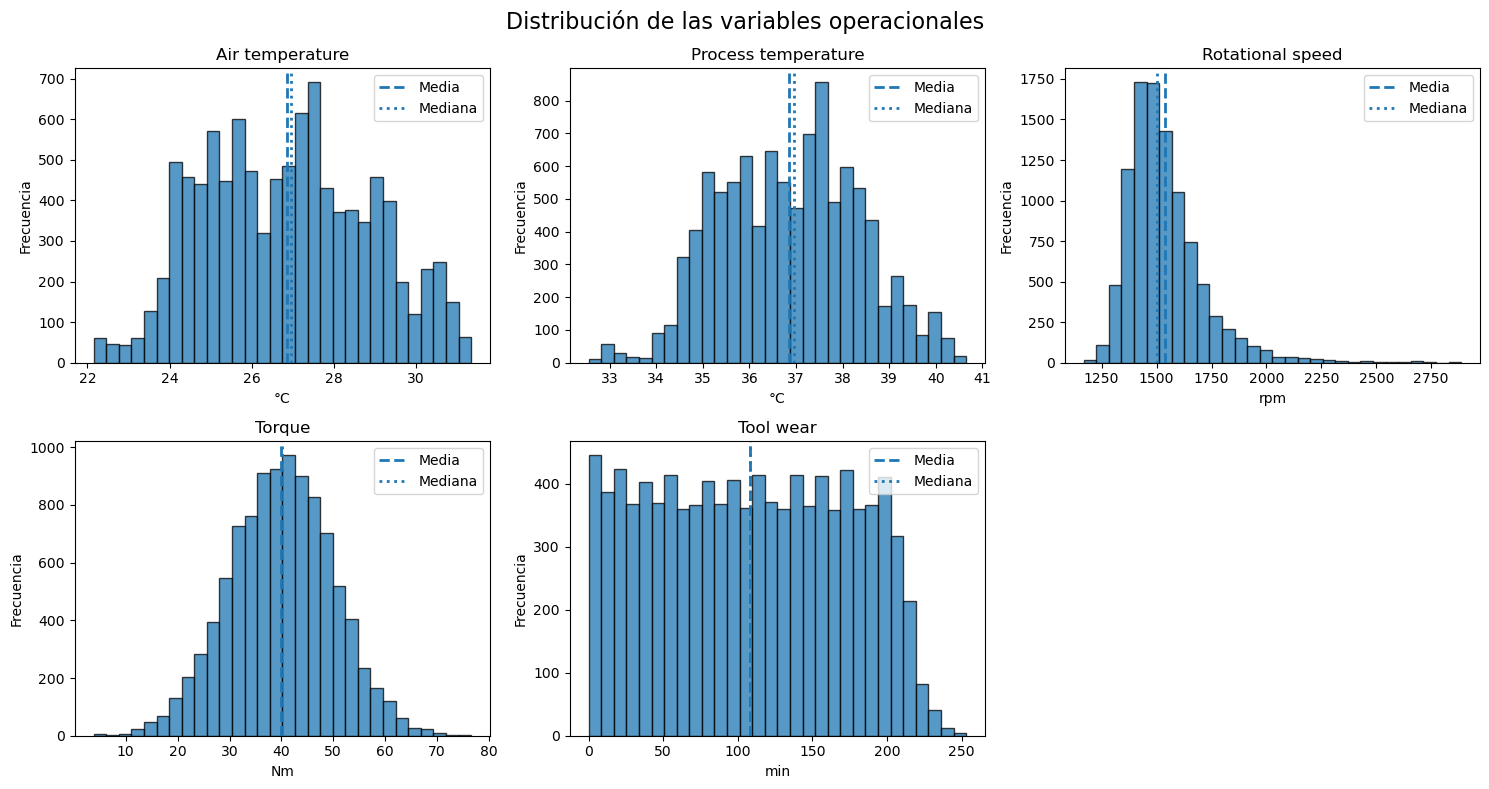

In [52]:
unidades = {
    "Air temperature": "°C",
    "Process temperature": "°C",
    "Rotational speed": "rpm",
    "Torque": "Nm",
    "Tool wear": "min"
}

columnas_operacion = list(unidades.keys())

# Crear un histograma independiente para cada variable operacional.
fig, ejes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 8)
)

ejes = ejes.flatten()

for eje, columna in zip(ejes, columnas_operacion):
    eje.hist(
        df[columna],
        bins=30,
        alpha=0.75,
        edgecolor="black"
    )

    eje.axvline(
        df[columna].mean(),
        linestyle="--",
        linewidth=2,
        label="Media"
    )

    eje.axvline(
        df[columna].median(),
        linestyle=":",
        linewidth=2,
        label="Mediana"
    )

    eje.set_title(columna)
    eje.set_xlabel(unidades[columna])
    eje.set_ylabel("Frecuencia")
    eje.legend()

# Eliminar el sexto espacio porque solamente tenemos cinco variables.
fig.delaxes(ejes[-1])

fig.suptitle(
    "Distribución de las variables operacionales",
    fontsize=16
)

plt.tight_layout()
plt.show()


**Hallazgos:** Se observan diferentes comportamientos en la distribución de las variables:

- `Torque` presenta una distribución simétrica, la media y la mediana están alineadas en el centro (alrededor de 40 Nm).
- `Air temprature` y `Process temperature`,presentan baja asimetría y valores de media y mediana próximos, lo que refleja una distribución relativamente equilibrada de los datos.

- `Tool wear` presentan una distribución plana que cae al llegar a un punto entre los 200 y 240 min, esto se debe a que es un ciclo repetitivo, donde el proceso añade continuamente 2, 3 o 5 min de desgaste a la herramienta en cada ciclo. Al llegar a un punto crítico (entre 200 y 240 minutos), la herramienta se cambia y el contador vuelve a cero.

- `Rotational speed` presenta una marcada asimetría positiva con una cola extendida hacia valores altos de rpm, donde la media es desplazada a la derecha de la mediana debido a picos operativos.

**Decisión:**
Debido a la marcada asimetría de Rotational speed, se evaluarán diferentes transformaciones para determinar si resulta conveniente modificar su distribución antes del modelado.

## 4.2 Validación de distintas transformaciones para reducir asimetría.

Se comparan distintas transformaciones sobre la variable `Rotational speed` con el fin validar como reducen su asimetría:

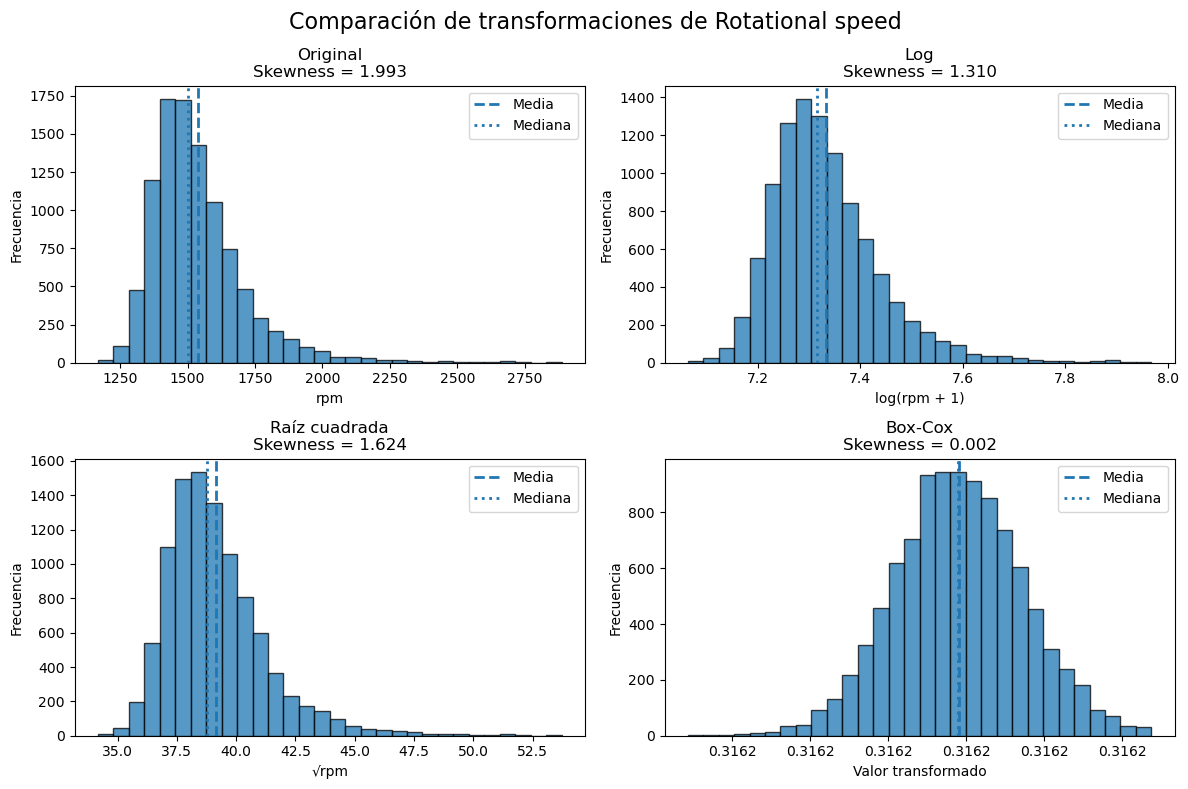

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.ticker import FuncFormatter

x = df["Rotational speed"].copy()

# Transformaciones
x_log = np.log1p(x)
x_sqrt = np.sqrt(x)
x_boxcox, lambda_boxcox = stats.boxcox(x)

transformaciones = {
    "Original": (x, "rpm"),
    "Log": (x_log, "log(rpm + 1)"),
    "Raíz cuadrada": (x_sqrt, "√rpm"),
    "Box-Cox": (x_boxcox, "Valor transformado")
}

fig, ejes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 8)
)

ejes = ejes.flatten()

for eje, (nombre, (datos, unidad)) in zip(
    ejes,
    transformaciones.items()
):
    datos = pd.Series(datos)

    eje.hist(
        datos,
        bins=30,
        alpha=0.75,
        edgecolor="black"
    )

    eje.axvline(
        datos.mean(),
        linestyle="--",
        linewidth=2,
        label="Media"
    )

    eje.axvline(
        datos.median(),
        linestyle=":",
        linewidth=2,
        label="Mediana"
    )

    eje.set_title(
        f"{nombre}\nSkewness = {datos.skew():.3f}"
    )

    eje.set_xlabel(unidad)
    eje.set_ylabel("Frecuencia")
    eje.legend()

    # Formato especial para Box-Cox
    if nombre == "Box-Cox":
        eje.xaxis.set_major_formatter(
            FuncFormatter(lambda valor, pos: f"{valor:.4f}")
        )

fig.suptitle(
    "Comparación de transformaciones de Rotational speed",
    fontsize=16
)

plt.tight_layout()
plt.show()

**Hallazgo:** El análisis comparativo de transformaciones sobre la variable `Rotational speed` muestra que las técnicas tradicionales como la raíz cuadrada o la transformación logarítmica no logran corregir de forma efectiva la asimetría positiva de la variable. Mientras que Box-Cox sí logró reducir la asimetría.
Sin embargo, el análisis de cual transformación elegir, no se puede reducir a elegir cual es el que produce la menor asimetría, si no que va a depender tambien del algoritmo que se va a utilizar, en el caso de algoritmos de detección de anomalías los algoritmos Isolation Forest, Local Outlier Factor (LOF), One-Class SVM y Autoencoders (Redes Neuronales), no requieren distribución normal de los datos. Por lo que no sería necesario aplicar esta transformación a menos que se utilice algún algoritmo especifico que lo requiera. 

**Decisión:** No transformar `Rotational speed` para reducir la asimetría de los datos.

## 4.3. Valores extremos: 

En la sección 9 del analisis de calidad, se identificó mediante el método IQR 418 valores extremos en `Rotational speed` y 69 en `Torque`. No se detectaron valores extremos en las temperaturas ni en el desgaste de herramienta.

**Torque:** Se análiza cuantos de los 69 valores extremos de torque corresponden a fallas.

In [ ]:
# Definir los límites del IQR para Torque
Q1 = df["Torque"].quantile(0.25)
Q3 = df["Torque"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")


Límite inferior: 12.80
Límite superior: 67.20


In [55]:
# Identificar registros extremos y no extremos
extremos_torque = df[
    (df["Torque"] < limite_inferior) |
    (df["Torque"] > limite_superior)
]

no_extremos_torque = df[
    (df["Torque"] >= limite_inferior) &
    (df["Torque"] <= limite_superior)
]

# Tasa de falla
tasa_falla_extremos = extremos_torque["Machine failure"].mean() * 100
tasa_falla_no_extremos = no_extremos_torque["Machine failure"].mean() * 100

comparacion_torque = pd.DataFrame({
    "Grupo": ["Extremos", "No extremos"],
    "Cantidad": [
        len(extremos_torque),
        len(no_extremos_torque)
    ],
    "Fallas": [
        extremos_torque["Machine failure"].sum(),
        no_extremos_torque["Machine failure"].sum()
    ],
    "Tasa de falla (%)": [
        tasa_falla_extremos,
        tasa_falla_no_extremos
    ]
})

comparacion_torque


,Grupo,Cantidad,Fallas,Tasa de falla (%)
0,Extremos,69,62,89.855072
1,No extremos,9931,295,2.970496


**Rotational speed:**

In [56]:
# Calcular límites mediante IQR
Q1 = df["Rotational speed"].quantile(0.25)
Q3 = df["Rotational speed"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificar valores extremos
extremos_rpm = df[
    (df["Rotational speed"] < limite_inferior) |
    (df["Rotational speed"] > limite_superior)
]

# Identificar valores no extremos
no_extremos_rpm = df[
    (df["Rotational speed"] >= limite_inferior) &
    (df["Rotational speed"] <= limite_superior)
]

# Resumen
fallas_extremos = extremos_rpm["Machine failure"].sum()
fallas_no_extremos = no_extremos_rpm["Machine failure"].sum()

tasa_extremos = extremos_rpm["Machine failure"].mean() * 100
tasa_no_extremos = no_extremos_rpm["Machine failure"].mean() * 100

print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")

comparacion_rpm = pd.DataFrame({
    "Grupo": ["Extremos", "No extremos"],
    "Cantidad": [
        len(extremos_rpm),
        len(no_extremos_rpm)
    ],
    "Fallas": [
        fallas_extremos,
        fallas_no_extremos
    ],
    "Tasa de falla (%)": [
        tasa_extremos,
        tasa_no_extremos
    ]
})

comparacion_rpm

Límite inferior: 1139.50
Límite superior: 1895.50


,Grupo,Cantidad,Fallas,Tasa de falla (%)
0,Extremos,418,35,8.373206
1,No extremos,9582,322,3.360468


**Hallazgo:**

Torque: Los valores extremos de Torque presentan una relación considerable con las fallas de la máquina. De los 69 registros identificados como extremos mediante el criterio del IQR, 62 corresponden a fallas, lo que representa una tasa de falla de 89.86 %. En contraste, la tasa de falla entre los registros no extremos es de solo 2.97 %.

Rotational Speed: Aunque Rotational speed presenta 418 valores extremos según el criterio IQR, únicamente 35 de ellos corresponden a fallas. Este comportamiento puede estar relacionado con la forma en que se generó la variable en el dataset, ya que la velocidad rotacional depende de una potencia aproximadamente constante y del torque. Por lo tanto, valores elevados de velocidad pueden aparecer de manera natural cuando el torque disminuye, sin representar necesariamente una condición anómala.

**Decisión:** Mantener los valores extremos.

Justificación: Los valores extremos en variables Torque y Rotational speed se conservarán y se analizarán conjuntamente durante el modelado, ya que la relación entre ambas puede aportar información relevante para identificar comportamientos anómalos.

Los resultados muestran que un valor estadísticamente extremo no debe interpretarse automáticamente como una anomalía operacional. Mientras que los extremos de Torque están fuertemente asociados con fallas, la mayoría de los extremos de Rotational speed corresponden a registros sin falla. Esto refuerza la necesidad de interpretar las variables dentro de su contexto operacional y de forma conjunta.

## 4.4 Escalado

**Hallazgos:**

Los valores presentan distintas escalas y únidades de medición además de valores extremos: 

**Decisión:** Aplicar RobustScaler durante el preprocesamientode forma general a las variables numéricas antes del entrenamiento. Aunque algunos algortimos como Isolation Forest no requiere escalado, esta transformación permite mantener un proceso de preparación homogéneo para todos los modelos y resulta adecuada para los algoritmos sensibles a escala, considerando además la presencia de valores extremos en el dataset.

Justificación: StandardScaler usa media y desviación estándar, así que es más sensible a valores extremos. RobustScaler usa mediana e IQR, por lo que utiliza estadísticas robustas para que los valores extremos tengan menor influencia sobre los parámetros utilizados para escalar.

- `StandardScaler`:

$$
z = \frac{x - \mu}{\sigma}
$$

- `RobustScaler`:

$$
x' = \frac{x - \text{mediana}}{IQR}
$$

## 4.5 Desbalance de clases 

El desbalance de Machine failure fue analizado previamente en el apartado 10. Desbalance de la variable objetivo del diagnóstico de calidad, por lo que no se repite su visualización en esta sección.

**Decisión:**

No se aplicará ningún tratamiento sobre el desbalance durante la preparación de datos, ya que el problema se abordará mediante técnicas de detección de anomalías y no requieren Machine failure como variable de entrada durante el entrenamiento. La distribución original de los datos se conservará y Machine failure se utilizará posteriormente como referencia para evaluar la capacidad de los modelos para identificar registros asociados con fallas. El desbalance será considerado principalmente durante la evaluación mediante métricas como precision, recall, F1-score

## 4.6 Tasa de falla según tipo de producto

Se analiza la frecuencia de fallas para cada categoría de Type con el fin de determinar si la proporción de fallas cambia según la calidad del producto. Para evitar que las diferencias en la cantidad de registros por categoría afecten la comparación, se utiliza la tasa de falla y no únicamente el número absoluto de fallas.

In [57]:
failure_by_type = (
    df.groupby("Type")["Machine failure"]
    .agg(
        Cantidad="count",
        Fallas="sum",
        Tasa_falla="mean"
    )
)

failure_by_type["Tasa_falla"] = (
    failure_by_type["Tasa_falla"] * 100
).round(2)

failure_by_type

,Cantidad,Fallas,Tasa_falla
Type,,,
H,1003,25,2.49
L,6000,247,4.12
M,2997,85,2.84


**Hallazgo:**

La tasa de falla presenta diferencias entre los tipos de producto. El tipo L tiene la mayor tasa de falla (4,12 %), seguido de M (2,84 %) y H (2,49 %). Aunque L también concentra la mayor cantidad absoluta de fallas (247), esto se debe a que es la categoría con más observaciones (6000 registros).

La comparación mediante tasas muestra que la diferencia no se debe únicamente al tamaño de los grupos: proporcionalmente, las fallas también son más frecuentes en los productos tipo L.

**Decisión:** se conservará Type como característica del modelo, ya que la frecuencia relativa de fallas presenta diferencias entre las categorías y, por lo tanto, puede aportar información sobre el contexto operativo de cada observación. Al ser una variable categórica, se aplicará una codificación adecuada dentro del pipeline antes del entrenamiento.

## 4.7 Relaciones entre variables operativas

En el apartado 11. Correlación entre variables operacionales del diagnóstico de calidad se identificaron dos relaciones lineales elevadas. 

La temperatura del aire y la temperatura del proceso tienen una correlación positiva de 0,876. 

La velocidad de rotación y el torque tienen una correlación negativa de -0,875.

Debido a su magnitud y relevancia física, se profundiza gráficamente en ambas relaciones.

### 4.7.1 Tempeatura del aire y del proceso

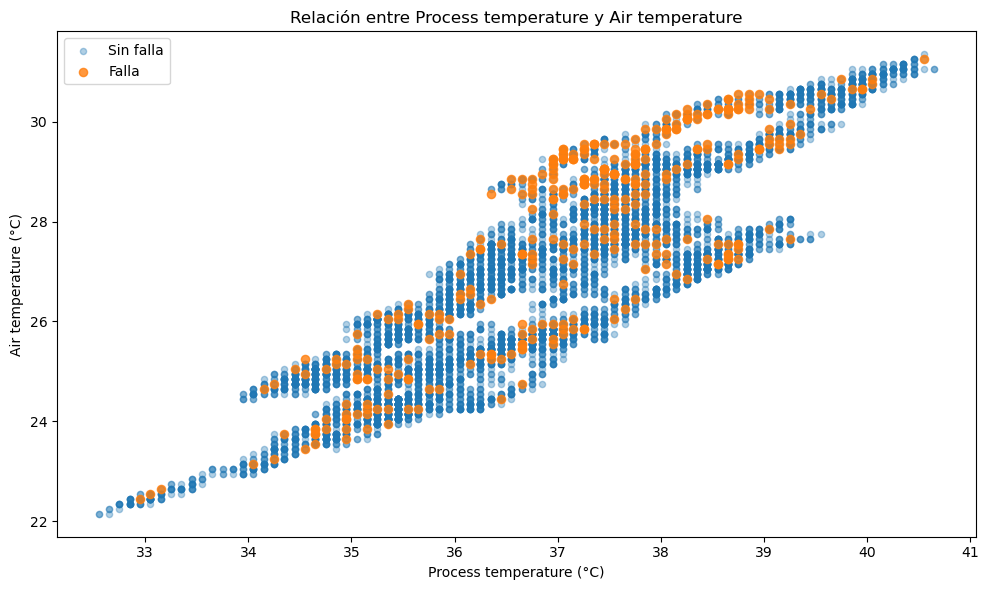

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Registros sin falla
normal = df[df["Machine failure"] == 0]

plt.scatter(
    normal["Process temperature"],
    normal["Air temperature"],
    alpha=0.35,
    s=20,
    label="Sin falla"
)

# Registros con falla
falla = df[df["Machine failure"] == 1]

plt.scatter(
    falla["Process temperature"],
    falla["Air temperature"],
    alpha=0.8,
    s=35,
    label="Falla"
)

plt.xlabel("Process temperature (°C)")
plt.ylabel("Air temperature (°C)")
plt.title("Relación entre Process temperature y Air temperature")
plt.legend()

plt.tight_layout()
plt.show()

**Hallazgo: ** Se observa una relación positiva entre Air temperature y Process temperature, donde ambas variables tienden a aumentar conjuntamente. Los registros con falla se encuentran mayormente dentro de la misma tendencia que los registros sin falla, sin formar una región claramente separada. Esto indica que la relación entre ambas temperaturas, por sí sola, no permite distinguir de forma evidente las condiciones de falla.

**Decisión:**Mantener ambas variables para el modelado, pero analizar también características derivadas de su relación, como la diferencia de temperatura entre proceso y aire, ya que esta podría aportar información adicional que no se observa al analizar únicamente los valores absolutos.

### 4.7.2 Torque y velocidad de rotación



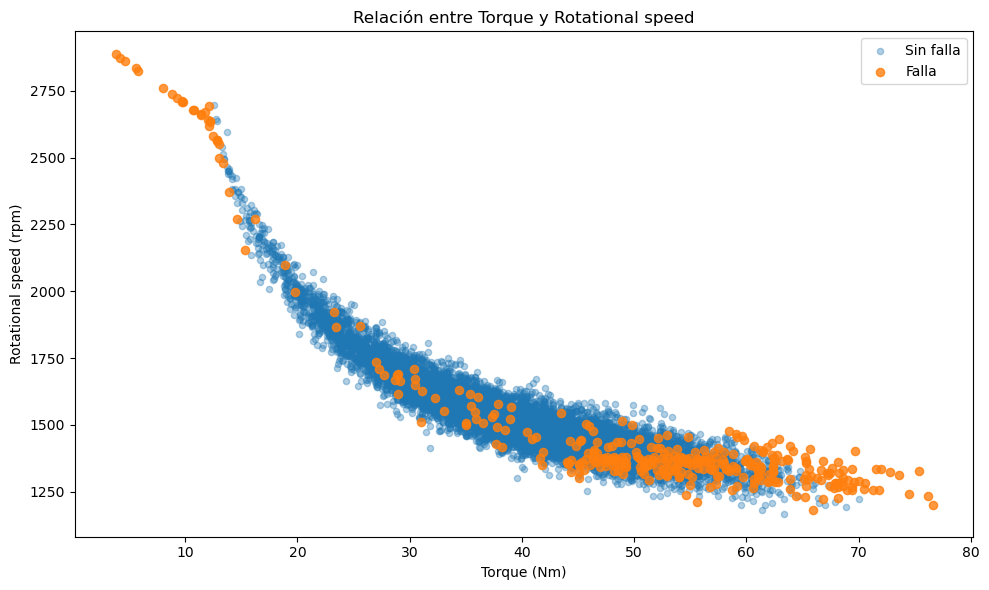

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Registros sin falla
sin_falla = df[df["Machine failure"] == 0]

plt.scatter(
    sin_falla["Torque"],
    sin_falla["Rotational speed"],
    alpha=0.35,
    s=20,
    label="Sin falla"
)

# Registros con falla
falla = df[df["Machine failure"] == 1]

plt.scatter(
    falla["Torque"],
    falla["Rotational speed"],
    alpha=0.8,
    s=35,
    label="Falla"
)

plt.xlabel("Torque (Nm)")
plt.ylabel("Rotational speed (rpm)")
plt.title("Relación entre Torque y Rotational speed")

plt.legend()
plt.tight_layout()
plt.show()

Al analizar la grafica de relación entre el Torque y la Rotational speed, se observa una relación inversa no lineal, es decir cuando el torque disminuye, la velocidad aumenta; cuando el torque aumenta, la velocidad disminuye. Esto es consistente debido a que la velocidad se calculó con una potencia  constante. 

$P = \tau \omega$


Si la potencia ($P$) se mantiene aproximadamente constante, la velocidad angular y el torque se vuelven inversamente proporcionales:

$\omega \propto \frac{1}{\tau}$

Las fallas se presentan principalmente en regiones extremas de esta relación, tanto para combinaciones de bajo torque y alta velocidad como de alto torque y baja velocidad. Esto indica que valores extremos de Rotational speed no necesariamente representan una anomalía por sí solos, ya que pueden corresponder a una condición operacional coherente con el nivel de torque.

**Hallazgo:** Se observa una relación inversa marcada entre Torque y Rotational speed, consistente con la relación entre ambas variables bajo una potencia aproximadamente constante. Los registros con falla se encuentran distribuidos a lo largo del patrón general, aunque presentan una mayor presencia en algunas combinaciones extremas de bajo torque con alta velocidad y de alto torque con menor velocidad.

**Decisión:**Mantener ambas variables para el modelado, pero analizar también características derivadas de su relación, como la potencia, ya que esta podría aportar información adicional que no se observa al analizar únicamente los valores absolutos.

## 4.8 Condiciones operativas según presencia de falla

Comparar la distribución de las variables operacionales entre registros con y sin falla, con el fin de identificar si las fallas se presentan bajo condiciones diferentes de operación.

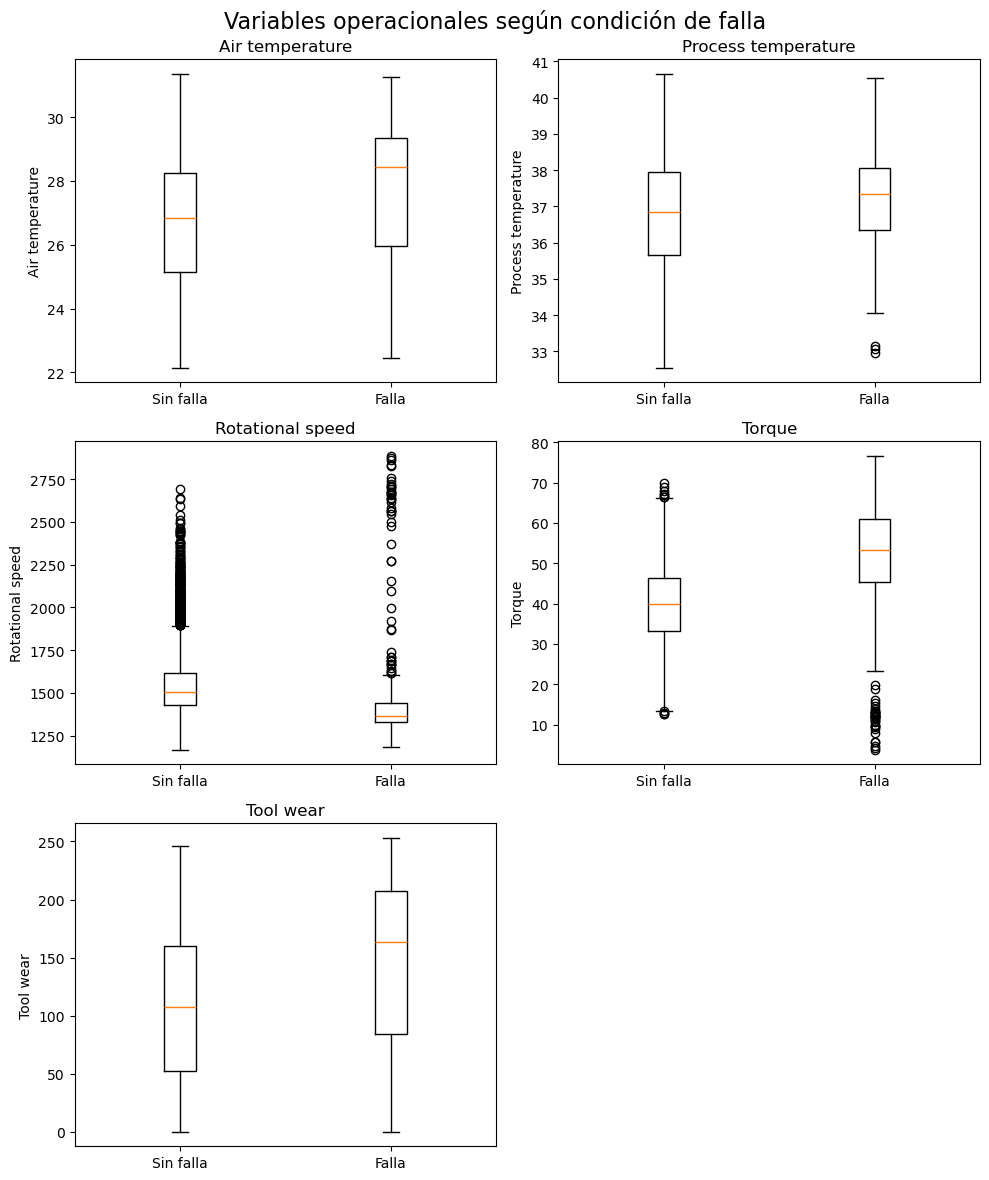

In [60]:
import matplotlib.pyplot as plt

variables = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear"
]

fig, ejes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(10, 12)
)

ejes = ejes.flatten()

for eje, variable in zip(ejes, variables):

    datos_normal = df[df["Machine failure"] == 0][variable]
    datos_falla = df[df["Machine failure"] == 1][variable]

    eje.boxplot(
        [datos_normal, datos_falla],
        tick_labels=["Sin falla", "Falla"]
    )

    eje.set_title(variable)
    eje.set_ylabel(variable)

fig.delaxes(ejes[-1])

fig.suptitle(
    "Variables operacionales según condición de falla",
    fontsize=16
)

plt.tight_layout()
plt.show()

**Hallazgos:** Al comparar las variables operacionales según la condición de falla, se observan diferencias entre ambos grupos:

- Air temperature y Process temperature: En la condición de falla, se observan temperaturas ligeramente más altas, esto podría estar relacionado a algunos mecanismos de falla térmica definidos en el dataset como las fallas de disipación de calor (HDF), ya que cuando el sistema no enfria la maquina correctamente, la temperatura del proceso y del aire incrementan. 

- Rotational speed y Torque: En condiciones normales, la velocidad de rotación tiene muchos valores atípicos altos y el torque está centrado. Sin embargo, al ocurrir una falla, el comportamiento en general cambia el Torque aumenta mientras que la Velocidad de rotación disminuye. Esto podría estar relacionado a las fallas por sobreesfuerzo (OSF) y fallas de potencia (PWF), ya que cuando la maquina sufre un atasco o sobreesfuerzo el motor va a exigir el torque máximo disponible y por ende las revoluciones por minuto caen de golpe debido a la resistencia mécanica.

- Tool wear: En la condicion de falla el tiempo acumulado es mayor, relacionado a una falla por desgaste (TWF), confirmando que a mayor tiempo de desgaste acumulado es más probable que la maquina falle.

En general, aunque algunas variables presentan diferencias en su distribución según la condición de falla, ninguna permite separar claramente los registros con y sin falla cuando se analiza de manera individual.

**Decisión:** 
Debido a que los valores de las variables se superponen entre registros con y sin falla, ninguna variable por sí sola permite distinguir claramente ambos grupos. Por esta razón, el modelado deberá considerar la combinación de varias variables operacionales para identificar patrones anómalos.

Se decide implementar una etapa de ingeniería de características (feature engineering) que sintetice estas interdependencias físicas en tres variables de interacción.



**Hallazgo:** Los boxplots muestran que Torque y Tool wear presentan diferencias entre los registros con y sin falla, aunque existe un solapamiento importante por lo que ninguna de las dos variables permite distinguir claramente las fallas cuando se analiza de forma individual.
Debido a que el modo de falla por sobreesfuerzo del dataset considera conjuntamente estas variables, se propone evaluar una característica de interacción entre ambas.
 

**Decisión:** Se evaluará una variable de interacción entre Torque y Tool wear mediante su producto, con el objetivo de representar conjuntamente la carga mecánica y el desgaste acumulado de la herramienta. En el dataset utilizan ambas variables para determinar la falla por sobreesfuerzo (OSF) al multiplicar el toque por el toolwear por lo que esta variable podría ser útil para la identificación de anomalías.


## 4.9 Naturaleza multivariada de las anomalías

Los análisis individuales y bivariados muestran que las fallas no se caracterizan únicamente por valores extremos de una sola variable. Algunos valores extremos corresponden a condiciones normales, mientras que diferentes combinaciones de torque, velocidad, temperatura y desgaste aparecen asociadas con fallas.

**Decisión:** El modelado se abordará mediante métodos de detección de anomalías multivariados.


# 5. Ingeniería de Características (Feature engineering) 

A partir de los hallazgos obtenidos durante el análisis exploratorio, se definieron nuevas variables con el objetivo de representar relaciones entre las condiciones operativas de la máquina que podrían no quedar reflejadas al analizar cada variable de forma independiente.

Las variables derivadas se seleccionaron considerando tanto los patrones observados en el EDA como la relación física entre algunas de las variables originales.

## 5.1 Diferencia de temperatura

Durante el análisis de Air temperature y Process temperature se observó una relación positiva entre ambas variables. Sin embargo, los registros con falla se encuentran mayormente dentro del mismo patrón observado para los registros sin falla, por lo que los valores absolutos de las temperaturas no permiten diferenciar claramente ambos grupos.

Debido a lo anterior, se propone calcular la diferencia entre la temperatura del proceso y la temperatura del aire (Temp Diff)

$$
\Delta T = T_{process} - T_{air}
$$

como variable candidata para el modelado y evaluar si aporta información adicional para la detección de anomalías.

## 5.2 Potencia

En el EDA se identificó una relación inversa marcada entre Torque y Rotational speed. Los registros con falla no se concentran únicamente en valores extremos de una de estas variables, sino que aparecen bajo distintas combinaciones de torque y velocidad.

Debido a que ambas variables se relacionan mediante la potencia mecánica, se propone calcular la potencia (Power) como variable candidata para el modelado y evaluar si aporta información adicional para la detección de anomalías.

Primero, la velocidad rotacional se convierte de revoluciones por minuto a radianes por segundo para obtener la velocidad angular:

$$
\omega = \frac{2\pi \cdot RPM}{60}
$$

Posteriormente, se calcula la potencia:

$$
P = \tau \cdot \omega
$$

donde:

$P$ = potencia mecánica en watts (W)<br>
$\tau$ = torque en newton-metro (Nm) <br>
$\omega$ = velocidad angular en rad/s

## 5.3 Interacción entre Torque y Tool wear

Los boxplots mostraron diferencias en el comportamiento de Torque y Tool wear entre los registros con y sin falla. Sin embargo, existe solapamiento entre ambos grupos cuando estas variables se analizan individualmente.

Por esta razón, se propone crear una variable de interacción entre la carga mecánica y el desgaste acumulado de la herramienta :


Torque_ToolWear_Product = $ Torque \times ToolWear $



Esta característica permite representar situaciones en las que una determinada carga puede tener un efecto diferente dependiendo del nivel de desgaste de la herramienta.

## 5.4 Evaluación de las nuevas características

Las variables creadas no se asumirán automáticamente como mejores que las variables originales. Su utilidad se evaluará posteriormente durante los experimentos de modelado.


Las variables originales utilizadas para construir estas características también se conservarán, ya que mantienen información directa e interpretable sobre las condiciones de operación. La creación de una variable derivada no implica necesariamente que esta sustituya toda la información contenida en sus variables de origen.

## Resumen de Tratamientos / Acciones para el pipeline

| Tratamiento                         | Acción a aplicar                                                                                                                                                                                                                                                |
| ----------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Imputación**                      | No requerida, debido a que no se identificaron valores faltantes.                                                                                                                                                                                               |
| **Eliminación de registros**        | No requerida. No se identificaron duplicados ni registros físicamente imposibles que justifiquen su eliminación.                                                                                                                                                |
| **Corrección de inconsistencias**   | Corregir los 18 registros con `RNF = 1` y `Machine failure = 0`, asignando `Machine failure = 1`. Los 9 registros con `Machine failure = 1` sin un tipo específico de falla se conservan.                                                                       |
| **Tratamiento de valores extremos** | Se conservan porque pueden representar comportamientos anómalos relevantes para el objetivo del proyecto.                                                                                                                          |
| **Variables de identificación**     | Excluir `UID` y `Product ID` de las características del modelo y conservarlas únicamente para trazabilidad.                                                                                                                                                     |
| **Variables de falla**              | Excluir `Machine failure`, `TWF`, `HDF`, `PWF`, `OSF` y `RNF` de las características de entrada para evitar fuga de información. Se conservarán como referencia para análisis y evaluación.                                                                        |
| **Codificación de datos**           | Codificar `Type` mediante **One-Hot Encoding**.                                                                                                                                                                                                                 |
| **Cambio de unidades**              | Mantener las temperaturas en Kelvin para el pipeline. La conversión a °C puede utilizarse únicamente con fines de interpretación o visualización, ya que no aporta información adicional al modelo.                                                             |
| **Transformación por asimetría**    | No aplicar una transformación general en esta etapa. Evaluar su necesidad según el comportamiento y los requerimientos de cada algoritmo.                                                                                                                       |
| **Escalado**                        | Aplicar RobustScaler a las variables numéricas dentro del pipeline. |
| **Desbalance**                      | No aplicar técnicas de balanceo como SMOTE o submuestreo. `Machine failure` no se utilizará para entrenar los detectores de anomalías, sino como referencia para su evaluación.                                                                                 |
| **Feature Engineering**             |Crear `Temperature difference`, `Power` y `Torque_ToolWear`. Las variables se conservarán inicialmente por su relación con los mecanismos físicos de falla y se evaluará posteriormente su aporte al desempeño de los modelos.                                                                             |

